In [2]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:

from google.colab import files
uploaded = files.upload()


# Carregar os dados
df_treino = pd.read_csv("tictactoe_treino.csv")
df_teste = pd.read_csv("tictactoe_teste.csv")
df_validacao = pd.read_csv("tictactoe_validacao.csv")

# Mapeamento das letras para números
mapa = {'x': 1, 'o': -1, 'b': 0}  # 'x' = 1, 'o' = -1, 'b' = 0 (empty)

# Aplicar o mapeamento nos dados
df_treino = df_treino.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
df_teste = df_teste.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
df_validacao = df_validacao.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)

# Separar as features (X) e os rótulos (y) para treino, teste e validação
X_treino = df_treino.drop(columns=['class'])
y_treino = df_treino['class']

X_teste = df_teste.drop(columns=['class'])
y_teste = df_teste['class']

X_validacao = df_validacao.drop(columns=['class'])
y_validacao = df_validacao['class']



Saving tictactoe_teste.csv to tictactoe_teste.csv
Saving tictactoe_treino.csv to tictactoe_treino.csv
Saving tictactoe_validacao.csv to tictactoe_validacao.csv


<ipython-input-3-18b5f0277fbe>:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_treino = df_treino.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
<ipython-input-3-18b5f0277fbe>:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_teste = df_teste.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)
<ipython-input-3-18b5f0277fbe>:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_validacao = df_validacao.applymap(lambda x: mapa.get(x, x) if isinstance(x, str) else x)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

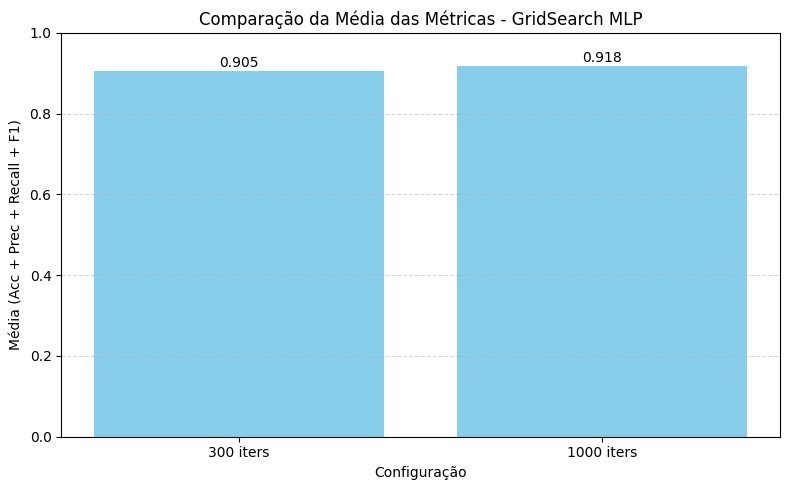

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Parâmetros para testar
param_grid = {
    'hidden_layer_sizes': [(40,)],
    'learning_rate_init': [0.01, 0.05],
    'momentum': [0.5, 0.9]
}

# Guardar os resultados
resultados = []

# Rodar GridSearchCV com diferentes max_iter
for max_iter in [300, 1000]:
    clf = MLPClassifier(solver='adam', max_iter=max_iter)
    grid = GridSearchCV(clf, param_grid, cv=3)
    grid.fit(X_treino, y_treino)

    # Melhor modelo encontrado
    melhor_modelo = grid.best_estimator_
    y_pred = melhor_modelo.predict(X_validacao)

    # Avaliação
    acc = accuracy_score(y_validacao, y_pred)
    prec = precision_score(y_validacao, y_pred, average='macro')
    rec = recall_score(y_validacao, y_pred, average='macro')
    f1 = f1_score(y_validacao, y_pred, average='macro')
    media = (acc + prec + rec + f1) / 4

    resultados.append({
        'max_iter': max_iter,
        'params': grid.best_params_,
        'acc': acc,
        'prec': prec,
        'rec': rec,
        'f1': f1,
        'media': media
    })

# Plotar gráfico
labels = [f"{r['max_iter']} iters" for r in resultados]
medias = [r['media'] for r in resultados]

plt.figure(figsize=(8, 5))
plt.bar(labels, medias, color='skyblue')
plt.title("Comparação da Média das Métricas - GridSearch MLP")
plt.ylabel("Média (Acc + Prec + Recall + F1)")
plt.xlabel("Configuração")
plt.ylim(0, 1)
for i, v in enumerate(medias):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Inicializar e treinar o modelo
clf = MLPClassifier(solver='adam', hidden_layer_sizes=(40), learning_rate_init=0.05, momentum=0.5, verbose=True)
clf.fit(X_treino, y_treino)

# Avaliar o modelo na validação
y_pred_validacao = clf.predict(X_validacao)

# Exibir as previsões com os rótulos reais
# print("Previsões e Rótulos Reais no Conjunto de Validação:")
# for i in range(len(y_validacao)):
#     print(f"Real: {y_validacao.iloc[i]}, Previsto: {y_pred_validacao[i]}")

# Relatório de desempenho na validação
print("Desempenho na validação:")
print(classification_report(y_validacao, y_pred_validacao))

# Avaliar o modelo nos dados de teste
y_pred_teste = clf.predict(X_teste)

# Relatório de desempenho no teste
print("Desempenho no teste:")
print(classification_report(y_teste, y_pred_teste))

# Acurácia no teste
accuracy = accuracy_score(y_teste, y_pred_teste)
print(f"Acurácia no teste: {accuracy:.2f}")

print(clf.classes_)


Iteration 1, loss = 1.23051358
Iteration 2, loss = 0.85205833
Iteration 3, loss = 0.68103130
Iteration 4, loss = 0.58739918
Iteration 5, loss = 0.50831796
Iteration 6, loss = 0.43753030
Iteration 7, loss = 0.39474773
Iteration 8, loss = 0.36157932
Iteration 9, loss = 0.34770122
Iteration 10, loss = 0.31089858
Iteration 11, loss = 0.28333684
Iteration 12, loss = 0.26966522
Iteration 13, loss = 0.25608917
Iteration 14, loss = 0.25954386
Iteration 15, loss = 0.22183745
Iteration 16, loss = 0.19829456
Iteration 17, loss = 0.18306653
Iteration 18, loss = 0.16930925
Iteration 19, loss = 0.15862989
Iteration 20, loss = 0.15748686
Iteration 21, loss = 0.13728781
Iteration 22, loss = 0.13452770
Iteration 23, loss = 0.12000069
Iteration 24, loss = 0.11272028
Iteration 25, loss = 0.10112692
Iteration 26, loss = 0.10851648
Iteration 27, loss = 0.10492783
Iteration 28, loss = 0.12959268
Iteration 29, loss = 0.11709619
Iteration 30, loss = 0.11681297
Iteration 31, loss = 0.10276863
Iteration 32, los